In [1]:
import os
import time
import random
import cv2

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras import models, Sequential, layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

from tensorflow.keras.optimizers import AdamW

In [2]:
import torch
torch.cuda.is_available()

True

### FACE LANDMARKER

In [3]:
'''
BASE_OPTIONS - is to specify model path
OPTIONS - is to specify:
 - output_face_blendshapes (True to get blendshapes)
 - output_facial_transformation_matrixes(True to get transformation matrixes)
 - num_faces(1 to detect one face)
DETECTOR - is to create face landmarker object to detect face landmarks
'''
BASE_OPTIONS = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
OPTIONS = vision.FaceLandmarkerOptions(base_options=BASE_OPTIONS,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
DETECTOR = vision.FaceLandmarker.create_from_options(OPTIONS)


TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"
# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"

EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/mlp_model.h5"

In [4]:
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [5]:
KEYPOINTS_DIR = "../affectnet_keypoints"
# keypoints_clahe_dir = "../clahe_keypoints"
# keypoints_mask_dir = "../mask_keypoints"

os.makedirs(KEYPOINTS_DIR, exist_ok=True)
# os.makedirs(keypoints_clahe_dir, exist_ok=True)
# os.makedirs(keypoints_mask_dir, exist_ok=True)

DATA_DIRS = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}
# data_dirs = {
#     "train": os.path.join(CLAHE_DATASET_PATH, "Train"),
#     "test": os.path.join(CLAHE_DATASET_PATH, "Test")
# }
# data_dirs = {
#     "train": os.path.join(MASK_DATASET_PATH, "Train"),
#     "test": os.path.join(MASK_DATASET_PATH, "Test")
# }

In [6]:
# # Loop through the dataset directories and extract keypoints for each image
# for split, split_dir in data_dirs.items():
#     LANDMARKS = 478
#     for class_name in sorted(os.listdir(split_dir)):
#         class_path = os.path.join(split_dir, class_name)
#         if not os.path.isdir(class_path):
#             continue

#         save_class_path = os.path.join(keypoints_dir, split, class_name)
#         os.makedirs(save_class_path, exist_ok=True)

#         for img_name in os.listdir(class_path):
#             if img_name.startswith("."):
#                 continue

#             img_path = os.path.join(class_path, img_name)

#             img = cv2.imread(img_path)
#             if img is None:
#                 continue

#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = cv2.resize(img,IMG_SIZE)

#             mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)

#             results = detector.detect(mp_image)

#             if results.face_landmarks:
#                 face_landmarks = results.face_landmarks[0]
#                 if (len(face_landmarks) == LANDMARKS):
#                     keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
#                 else:
#                     continue
#             else:
#                continue

#             save_path = os.path.join(
#                 save_class_path,
#                 img_name.split('.')[0] + ".npy"
#             )
#             np.save(save_path, keypoints)

# print("Keypoints saved in folder:", keypoints_dir)

In [7]:
# check if kp saved correctly (should be 478 kp, 3 coordinates[x,y,z])
folder = "../affectnet_keypoints/train/contempt"
# folder = "../clahe_keypoints/train/contempt"
# folder = "../mask_keypoints/train/contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(478, 3)


In [8]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../affectnet_keypoints/train")
# X, y = load_keypoints_dataset("../clahe_keypoints/train")
# X, y = load_keypoints_dataset("../mask_keypoints/train")

In [9]:
print(y[:5])

['anger' 'anger' 'anger' 'anger' 'anger']


In [10]:
'''
LabelEncoder() - to convert string lbl to int
to_categorical() - to convert int lbl to one-hot encoding
reshape - to convert 3D array (samples, landmarks, coordinates) 
to 2D array (samples, features), because MLP expects 2D input (samples, features)

StandardScaler() - to standardize features by removing the mean and scaling to unit variance
(data is scaled to have a standard deviation of 1)
'''
le = LabelEncoder()
y = le.fit_transform(y) # to convert string labels to integers
# y = to_categorical(y) 


# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y # to keep class distribution in train/val splits
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)

# THEN standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

# (12830, 1434) (12830, 8)
# number of samples - 12830
# number of features per sample - 1434 (478 features * 3 x,y,z coordinates)

(12862, 1434) (12862,)


In [11]:
print(y[:5])

[0 0 0 0 0]


In [12]:
y[3400:3410]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
'''
apply a weight to each class based on its frequency
class weights given based on the formula:
n_samples / (n_classes * np.bincount(y))
- np.bincount(y) counts number of occurrences of each class in train lbl.
'''

num_classes = len(np.unique(y))
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights array:", class_weights)

Class weights array: {0: np.float64(1.345397489539749), 1: np.float64(1.2913654618473895), 2: np.float64(1.6422369765066394), 3: np.float64(1.3342323651452281), 4: np.float64(0.85975935828877), 5: np.float64(0.7288077969174978), 6: np.float64(0.6514384116693679), 7: np.float64(0.9490850059031877)}


In [14]:
model = tf.keras.Sequential([
    layers.Input(shape=(1434,)),
    
    # Block 1
    layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.4),

    # Block 2
    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),

    # Block 3
    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.2),

    layers.Dense(8, activation='softmax')
])

model.compile(
    optimizer=AdamW(learning_rate=1e-3), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       734,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,560 (3.45 MB)

 Trainable params: 901,768 (3.44 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [15]:
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
mc = ModelCheckpoint(
    SAVED_MODEL,
    monitor='val_loss',
    save_best_only=True
)
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3, #0.5
    patience=3,    
    min_lr=1e-6
)
csv_logger = CSVLogger('../logs/mlp_weighted_loss_training_log.csv')

In [16]:
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger,rlr]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
394/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3536 - loss: 1.8336

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3999 - loss: 1.6802 - val_accuracy: 0.5115 - val_loss: 1.3560 - learning_rate: 0.0010
Epoch 2/100
394/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4674 - loss: 1.5185

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4764 - loss: 1.4933 - val_accuracy: 0.5401 - val_loss: 1.2901 - learning_rate: 0.0010
Epoch 3/100
394/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4937 - loss: 1.4435

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4987 - loss: 1.4293 - val_accuracy: 0.5498 - val_loss: 1.2556 - learning_rate: 0.0010
Epoch 4/100
399/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5169 - loss: 1.3905

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5132 - loss: 1.3850 - val_accuracy: 0.5581 - val_loss: 1.2514 - learning_rate: 0.0010
Epoch 5/100
398/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5196 - loss: 1.3692

...

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6559 - loss: 1.0331 - val_accuracy: 0.6374 - val_loss: 1.0334 - learning_rate: 2.7000e-05
Epoch 45/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6608 - loss: 1.0239 - val_accuracy: 0.6343 - val_loss: 1.0352 - learning_rate: 2.7000e-05
Epoch 46/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6518 - loss: 1.0397 - val_accuracy: 0.6331 - val_loss: 1.0363 - learning_rate: 2.7000e-05
Epoch 47/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6550 - loss: 1.0301 - val_accuracy: 0.6381 - val_loss: 1.0346 - learning_rate: 2.7000e-05
Epoch 48/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6523 - loss: 1.0290 - val_accuracy: 0.6368 - val_loss: 1.0336 - learning_rate: 8.1000e-06
Epoch 49/100
395/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6463 - loss: 1.0455

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6484 - loss: 1.0340 - val_accuracy: 0.6356 - val_loss: 1.0326 - learning_rate: 8.1000e-06
Epoch 50/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6532 - loss: 1.0310 - val_accuracy: 0.6362 - val_loss: 1.0330 - learning_rate: 8.1000e-06
Epoch 51/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6532 - loss: 1.0210 - val_accuracy: 0.6359 - val_loss: 1.0329 - learning_rate: 8.1000e-06
Epoch 52/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6535 - loss: 1.0272 - val_accuracy: 0.6359 - val_loss: 1.0333 - learning_rate: 8.1000e-06
Epoch 53/100
396/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6545 - loss: 1.0361

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6535 - loss: 1.0270 - val_accuracy: 0.6362 - val_loss: 1.0324 - learning_rate: 2.4300e-06
Epoch 54/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6536 - loss: 1.0224 - val_accuracy: 0.6359 - val_loss: 1.0328 - learning_rate: 2.4300e-06
Epoch 55/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6581 - loss: 1.0219 - val_accuracy: 0.6356 - val_loss: 1.0324 - learning_rate: 2.4300e-06
Epoch 56/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6591 - loss: 1.0186 - val_accuracy: 0.6350 - val_loss: 1.0325 - learning_rate: 2.4300e-06
Epoch 57/100
398/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6572 - loss: 1.0243

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6580 - loss: 1.0177 - val_accuracy: 0.6359 - val_loss: 1.0322 - learning_rate: 1.0000e-06
Epoch 58/100
393/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6496 - loss: 1.0369

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6539 - loss: 1.0249 - val_accuracy: 0.6356 - val_loss: 1.0318 - learning_rate: 1.0000e-06
Epoch 59/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6575 - loss: 1.0201 - val_accuracy: 0.6346 - val_loss: 1.0319 - learning_rate: 1.0000e-06
Epoch 60/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6550 - loss: 1.0242 - val_accuracy: 0.6359 - val_loss: 1.0318 - learning_rate: 1.0000e-06
Epoch 61/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6550 - loss: 1.0260 - val_accuracy: 0.6359 - val_loss: 1.0322 - learning_rate: 1.0000e-06
Epoch 62/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6540 - loss: 1.0269 - val_accuracy: 0.6362 - val_loss: 1.0324 - learning_rate: 1.0000e-06
Epoch 63/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6577 - loss: 1.0291 - val_accuracy: 0.6353 - val_loss: 1.0322 - learning_rate: 1.0000e-06
Epoch 64/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy:

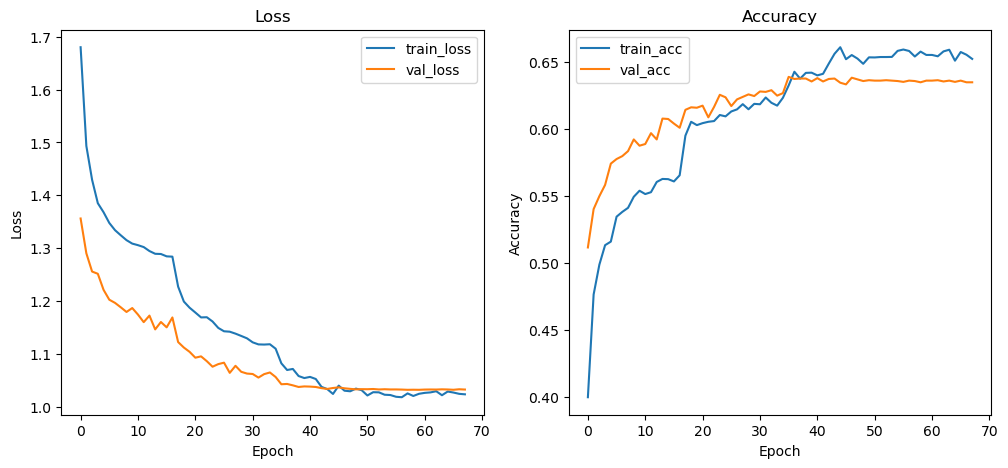

In [17]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [18]:
model = models.load_model(SAVED_MODEL)

In [19]:
# load test data
X_test, y_test = load_keypoints_dataset("../affectnet_keypoints/test")
# X_test, y_test = load_keypoints_dataset("../clahe_keypoints/test")
# X_test, y_test = load_keypoints_dataset("../mask_keypoints/test")

X_test = X_test.reshape(X_test.shape[0], -1)
# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
# y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
# X_test - NumPy array of extracted keypoints
# y_test_enc - integer labels from LabelEncoder
print("y_test_enc shape:", y_test_enc.shape)

X_test shape: (14480, 1434)
y_test_enc shape: (14480,)


In [20]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = y_test_enc

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6337 - loss: 1.3149
Test Accuracy: 63.37%, Test Loss: 1.3149
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step
Macro F1: 0.5897

Classification Report:

              precision    recall  f1-score   support

       anger       0.53      0.43      0.48      1705
    contempt       0.59      0.65      0.62      1312
     disgust       0.42      0.47      0.44      1243
        fear       0.54      0.45      0.49      1658
       happy       0.91      0.90      0.91      2703
     neutral       0.72      0.94      0.82      2367
         sad       0.53      0.54      0.54      1576
    surprise       0.49      0.38      0.43      1916

    accuracy                           0.63     14480
   macro avg       0.59      0.60      0.59     14480
weighted avg       0.62      0.63      0.62     14480



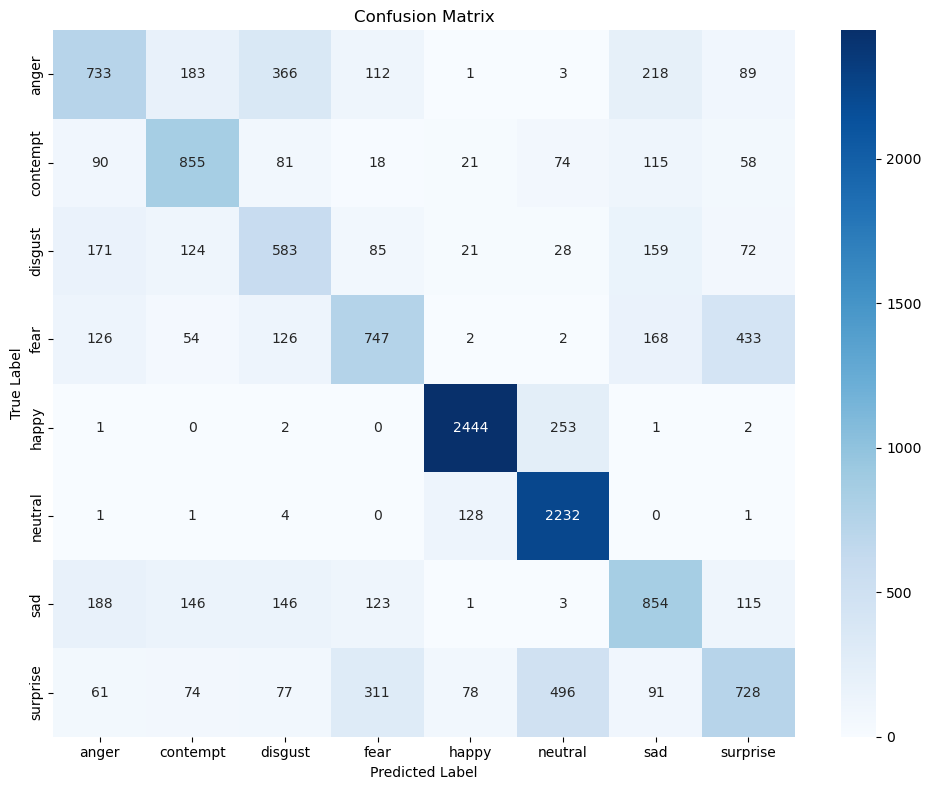

In [22]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")

# Predict probabilities
y_prob = model.predict(X_test, verbose=1)

# Predicted class indices
y_pred = np.argmax(y_prob, axis=1)

# True class indices
y_true = y_test_enc

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1: {macro_f1:.4f}")

# Class names from LabelEncoder
class_labels = le.classes_

# Classification report
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

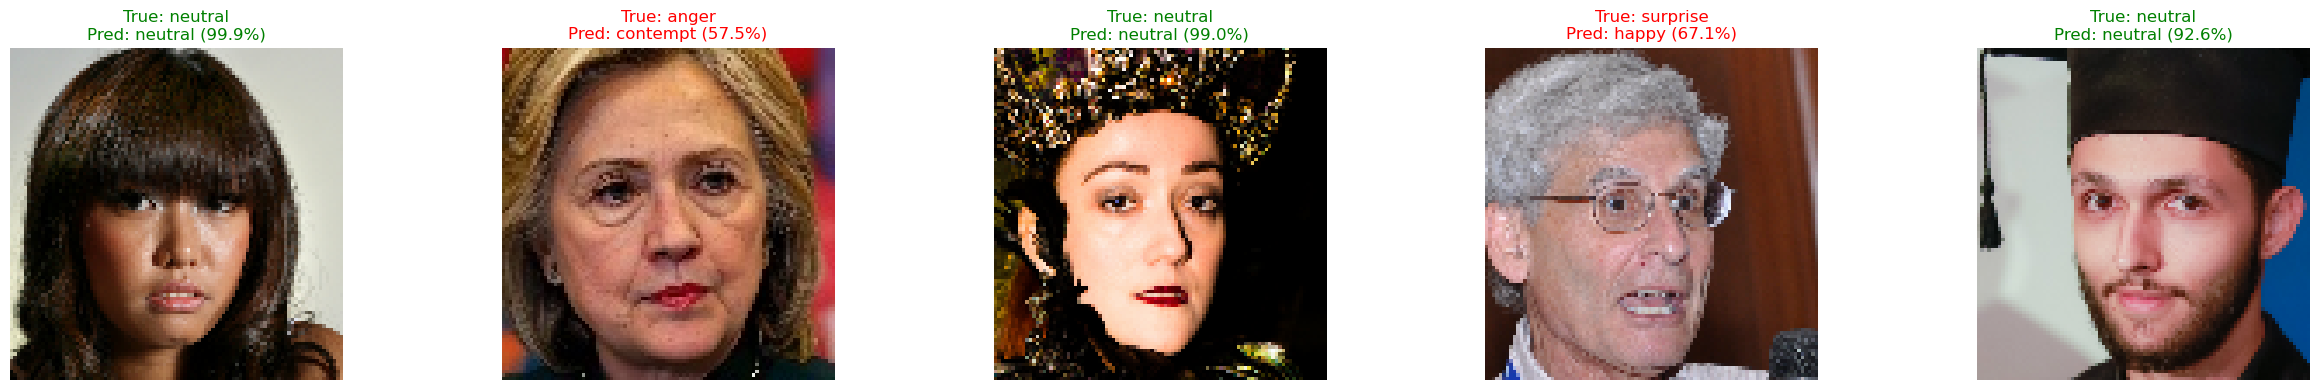

In [23]:
def predict_images_with_keypoints(image_dir, model, scaler, le, n=5):
    images_paths = []

    # collect all images
    for class_name in os.listdir(image_dir):
        class_path = os.path.join(image_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue
            images_paths.append((os.path.join(class_path, img_name), class_name))

    # pick random samples
    np.random.seed(RANDOM_SEED)
    samples = np.random.choice(len(images_paths), n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    for i, idx in enumerate(samples):
        img_path, true_label = images_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- KEYPOINT EXTRACTION ---
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        results = DETECTOR.detect(mp_image)

        if not results.face_landmarks:
            pred_label = "No face"
            confidence = 0
        else:
            face_landmarks = results.face_landmarks[0]

            keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
            keypoints = keypoints.reshape(1, -1)

            keypoints = scaler.transform(keypoints)

            pred_prob = model.predict(keypoints, verbose=0)[0]
            pred_idx = np.argmax(pred_prob)
            pred_label = le.classes_[pred_idx]
            confidence = pred_prob[pred_idx] * 100

        axes[i].imshow(img_rgb)
        axes[i].axis("off")

        color = "green" if pred_label == true_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_images_with_keypoints(
    "../affectnet_dataset/Test",
    model,
    scaler,
    le,
    n=5
)

In [24]:
# Divide by 1024**2 to convert bytes to megabytes
size_mb = os.path.getsize(SAVED_MODEL) / (1024**2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 10.39 MB
